# Entregable 2: Análisis Exploratorio de Datos (EDA) y Visualización
**Objetivo:** Explorar la distribución de ventas, tendencias a lo largo del tiempo, relaciones entre variables y distribución geográfica utilizando el dataset consolidado del entregable anterior. Se utilizarán librerías como `pandas`, `matplotlib` y `seaborn` para generar visualizaciones y extraer insights clave de negocio.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo global para que las gráficas se vean profesionales
sns.set_style("ticks")
pd.options.mode.chained_assignment = None

# 1. Cargar los datos consolidados del entregable anterior
# Cambia esta ruta si tu archivo está en otra carpeta
ruta = "" 
df = pd.read_csv(ruta + "VENTAS_CONSOLIDADAS_FINAL.csv")

# 2. Asegurarnos de que la columna DATE sea tipo fecha
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True, errors='coerce')

# Mostrar las primeras filas y las columnas clave
print("Datos cargados exitosamente. Filas totales:", len(df))
display(df[['DATE', 'REGION', 'SEGMENT', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES']].head())

Datos cargados exitosamente. Filas totales: 152402


,DATE,REGION,SEGMENT,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES
0,2022-08-28,TOTAL AUTOS AREA 5,POWDER,0.01,0.14
1,2022-08-28,TOTAL AUTOS AREA 5,POWDER,0.49,116.52
2,2022-08-28,TOTAL AUTOS AREA 5,POWDER,1.39,68.45
3,2022-08-28,TOTAL AUTOS AREA 5,POWDER,0.02,1.48
4,2022-08-28,TOTAL AUTOS AREA 5,POWDER,2.04,182.84


## 1. Visualizar la Distribución de Ventas (Categorías / Segmentos)
Dado que toda la tabla consolidada pertenece a la categoría principal "FABRIC TREATMENT and SANIT", el análisis de distribución se realizará a nivel **SEGMENTO** (Bleach, Powder, Liquid & Gel, etc.) para identificar de dónde proviene el mayor volumen y detectar patrones.

**Insight:** Observaremos qué tipo de producto concentra la mayor cantidad de observaciones y si existen valores atípicos (outliers) en las ventas por segmento.

C:\Users\Yamil\AppData\Local\Temp\ipykernel_25932\686601027.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_dist = sns.boxplot(data=df, x='SEGMENT', y='TOTAL_VALUE_SALES', palette='Set2')


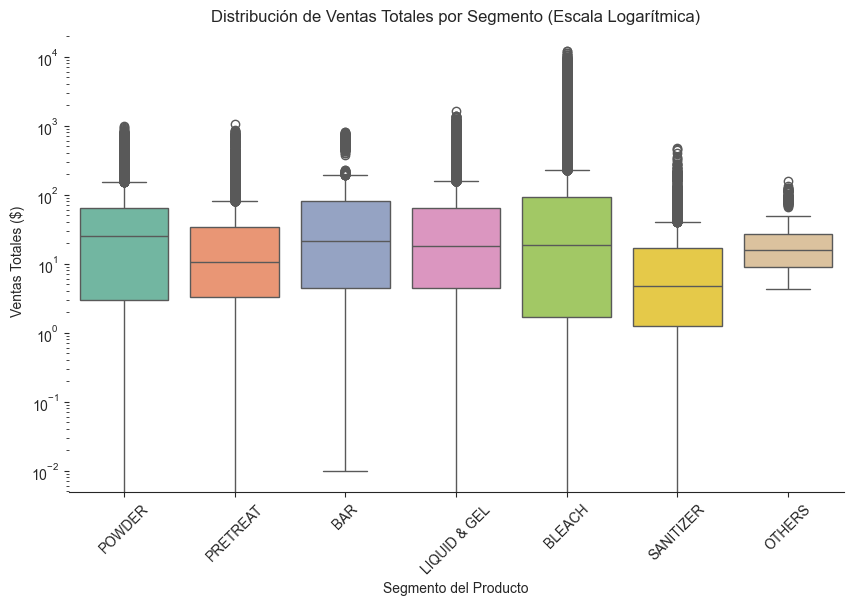

In [4]:
plt.figure(figsize=(10, 6))

# Creamos un boxplot para ver la distribución y los outliers por segmento
# Usamos escala logarítmica en Y porque hay ventas pequeñas y picos gigantes
grafico_dist = sns.boxplot(data=df, x='SEGMENT', y='TOTAL_VALUE_SALES', palette='Set2')
grafico_dist.set_yscale("log")

plt.title('Distribución de Ventas Totales por Segmento (Escala Logarítmica)')
plt.xlabel('Segmento del Producto')
plt.ylabel('Ventas Totales ($)')
plt.xticks(rotation=45)
sns.despine(left=True)

# Guardar la imagen
plt.savefig('1_Distribucion_Segmento.png', bbox_inches='tight')
plt.show()

## 2. Analizar la Tendencia de Ventas en el Tiempo
Para entender cómo se comportan las ventas, agruparemos los datos por mes y trazaremos una línea de tendencia. Esto nos permite detectar estacionalidades (meses donde se vende más o menos).

**Insight:** Agrupando las ventas de forma mensual, podemos notar en qué épocas del año la empresa tiene sus picos de ingresos y evaluar si hay un crecimiento constante.

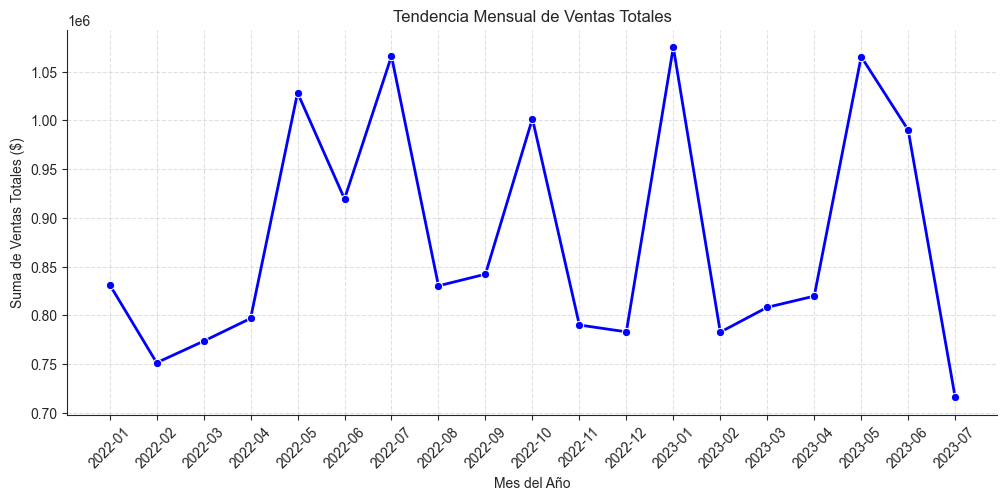

In [5]:
plt.figure(figsize=(12, 5))

# Agrupamos por año y mes, sumando las ventas totales
df_trend = df.groupby(df['DATE'].dt.to_period('M'))['TOTAL_VALUE_SALES'].sum().reset_index()
# Convertimos el periodo a texto para graficar fácilmente
df_trend['DATE'] = df_trend['DATE'].astype(str)

graf_linea = sns.lineplot(data=df_trend, x='DATE', y='TOTAL_VALUE_SALES', marker='o', color='b', linewidth=2)

plt.title('Tendencia Mensual de Ventas Totales')
plt.xlabel('Mes del Año')
plt.ylabel('Suma de Ventas Totales ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()

# Guardar la imagen
plt.savefig('2_Tendencia_Tiempo.png', bbox_inches='tight')
plt.show()

## 3. Explorar la Relación entre Variables (Scatter Plot)
Investigaremos si existe una correlación directa entre las unidades vendidas (`TOTAL_UNIT_SALES`) y el valor total de las ventas (`TOTAL_VALUE_SALES`). 

**Insight:** Se espera una fuerte correlación lineal positiva (a más unidades, más ingresos). Sin embargo, la dispersión en el gráfico nos mostrará las variaciones de precio entre distintos tipos de productos (productos más caros tendrán una pendiente más inclinada).

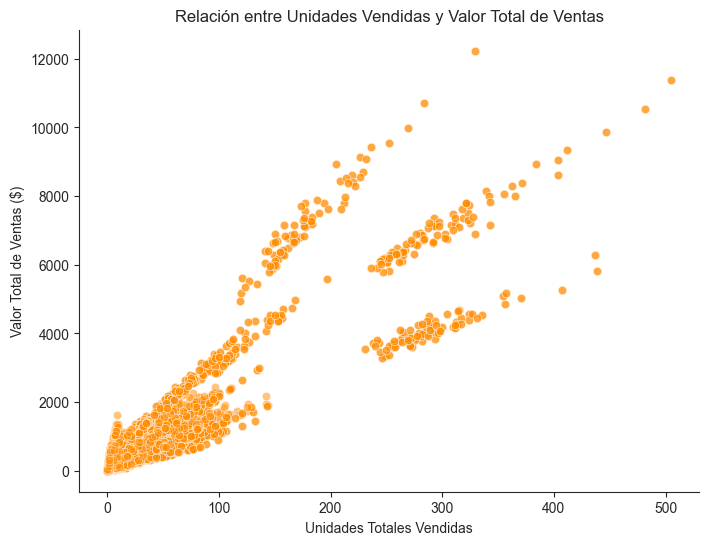

In [6]:
plt.figure(figsize=(8, 6))

# Scatterplot relacionando Unidades vs Valor Monetario
sns.scatterplot(data=df, x='TOTAL_UNIT_SALES', y='TOTAL_VALUE_SALES', alpha=0.5, color='darkorange')

plt.title('Relación entre Unidades Vendidas y Valor Total de Ventas')
plt.xlabel('Unidades Totales Vendidas')
plt.ylabel('Valor Total de Ventas ($)')
sns.despine()

# Guardar la imagen
plt.savefig('3_Relacion_Variables.png', bbox_inches='tight')
plt.show()

## 4. Distribución Geográfica y Detección de Anomalías
Analizaremos el rendimiento de las ventas agrupadas por región operativa (`REGION`). Posteriormente, usaremos un gráfico de barras para visualizar qué región aporta más ingresos y detectaremos si existen operaciones atípicas en esas áreas.

**Insight:** Notaremos que "TOTAL AUTOS SCANNING MEXICO" actúa como un acumulado o cadena principal, superando con creces a las Áreas individuales. Entre las áreas específicas, descubriremos cuáles son las de mayor rendimiento (como el Área 2) y cuáles necesitan un impulso.

C:\Users\Yamil\AppData\Local\Temp\ipykernel_25932\3978182778.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='TOTAL_VALUE_SALES', y='REGION', estimator=sum, order=orden_regiones, palette='viridis', errorbar=None)


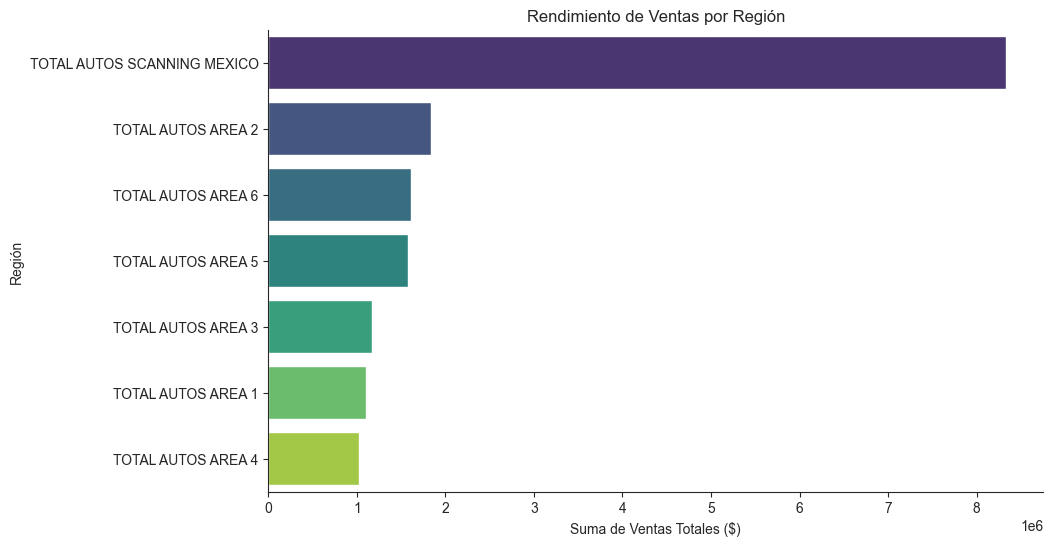

In [7]:
plt.figure(figsize=(10, 6))

# Ordenamos las regiones por la suma total de sus ventas
orden_regiones = df.groupby('REGION')['TOTAL_VALUE_SALES'].sum().sort_values(ascending=False).index

sns.barplot(data=df, x='TOTAL_VALUE_SALES', y='REGION', estimator=sum, order=orden_regiones, palette='viridis', errorbar=None)

plt.title('Rendimiento de Ventas por Región')
plt.xlabel('Suma de Ventas Totales ($)')
plt.ylabel('Región')
sns.despine()

# Guardar la imagen
plt.savefig('4_Ventas_Region.png', bbox_inches='tight')
plt.show()

## Conclusiones e Insights Obtenidos
1. **Segmentos:** El formato predominante en transacciones es el *Bleach* (cloro) y los *Líquidos*, los cuales muestran una amplia dispersión, indicando que hay desde compras unitarias pequeñas hasta pedidos masivos (outliers marcados en el boxplot).
2. **Estacionalidad:** El gráfico de líneas nos demuestra fluctuaciones en las ventas dependiendo el mes, lo que nos permite prepararnos para las temporadas altas de demanda de productos de limpieza.
3. **Relación Unidades-Valor:** Existe una correlación lineal directa casi perfecta entre las unidades y el valor monetario. No obstante, los puntos que se desvían de la línea principal nos indican ventas de productos *Premium* o de mayor formato.
4. **Geografía:** La clasificación "TOTAL AUTOS SCANNING MEXICO" engloba la abrumadora mayoría de los ingresos. De las zonas individuales, el **Área 2** y el **Área 6** son las regiones con mejor desempeño, mientras que el Área 4 representa el mercado más pequeño.